In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('df_eda.csv', index_col=0, parse_dates=True)

In [33]:
# Add time columns needed by all patterns below
df['month']  = df.index.month
df['hour']   = df.index.hour
df['season'] = df['month'].map({
    12:'Winter', 1:'Winter', 2:'Winter',
     3:'Spring', 4:'Spring', 5:'Spring',
     6:'Summer', 7:'Summer', 8:'Summer',
     9:'Autumn',10:'Autumn',11:'Autumn'
})

# Shared colours and labels — used in every chart below
CLASS_COLORS  = {'Excellent':'#2ecc71', 'Good':'#3498db', 'UFC':'#f39c12', 'Poor':'#e74c3c'}
SEASON_COLORS = {'Winter':'#3498db', 'Spring':'#2ecc71', 'Summer':'#e74c3c', 'Autumn':'#f39c12'}
MONTH_LABELS  = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
CLASS_ORDER   = ['Excellent', 'Good', 'UFC', 'Poor']
SEASON_ORDER  = ['Winter', 'Spring', 'Summer', 'Autumn']

print(f'Rows   : {len(df):,}')
print(f'Period : {df.index.min().date()}  to  {df.index.max().date()}')
print(f'Nulls  : {df.isnull().sum().sum()}  <- must be 0')
print(f'\nClass counts:')
print(df['WQI_Class'].value_counts().to_string())

Rows   : 37,730
Period : 2004-01-01  to  2006-02-25
Nulls  : 0  <- must be 0

Class counts:
WQI_Class
Excellent    22527
Good         13797
UFC           1259
Poor           147


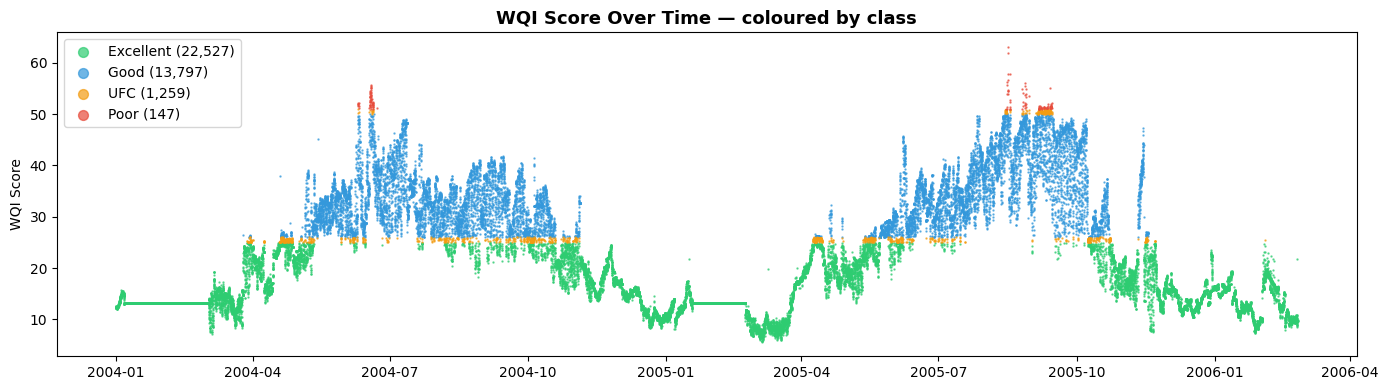

In [34]:
#   "WQI follows a clear yearly cycle — high in summer, low in winter.
#    The data is clean and the signal is real."

fig, ax = plt.subplots(figsize=(14, 4))

for cls, color in CLASS_COLORS.items():
    mask = df['WQI_Class'] == cls
    ax.scatter(df.index[mask], df['WQI'][mask],
               s=0.5, color=color, label=f'{cls} ({mask.sum():,})', alpha=0.7)

ax.set_title('WQI Score Over Time — coloured by class', fontsize=13, fontweight='bold')
ax.set_ylabel('WQI Score')
ax.legend(markerscale=10, loc='upper left')
plt.tight_layout()
plt.show()

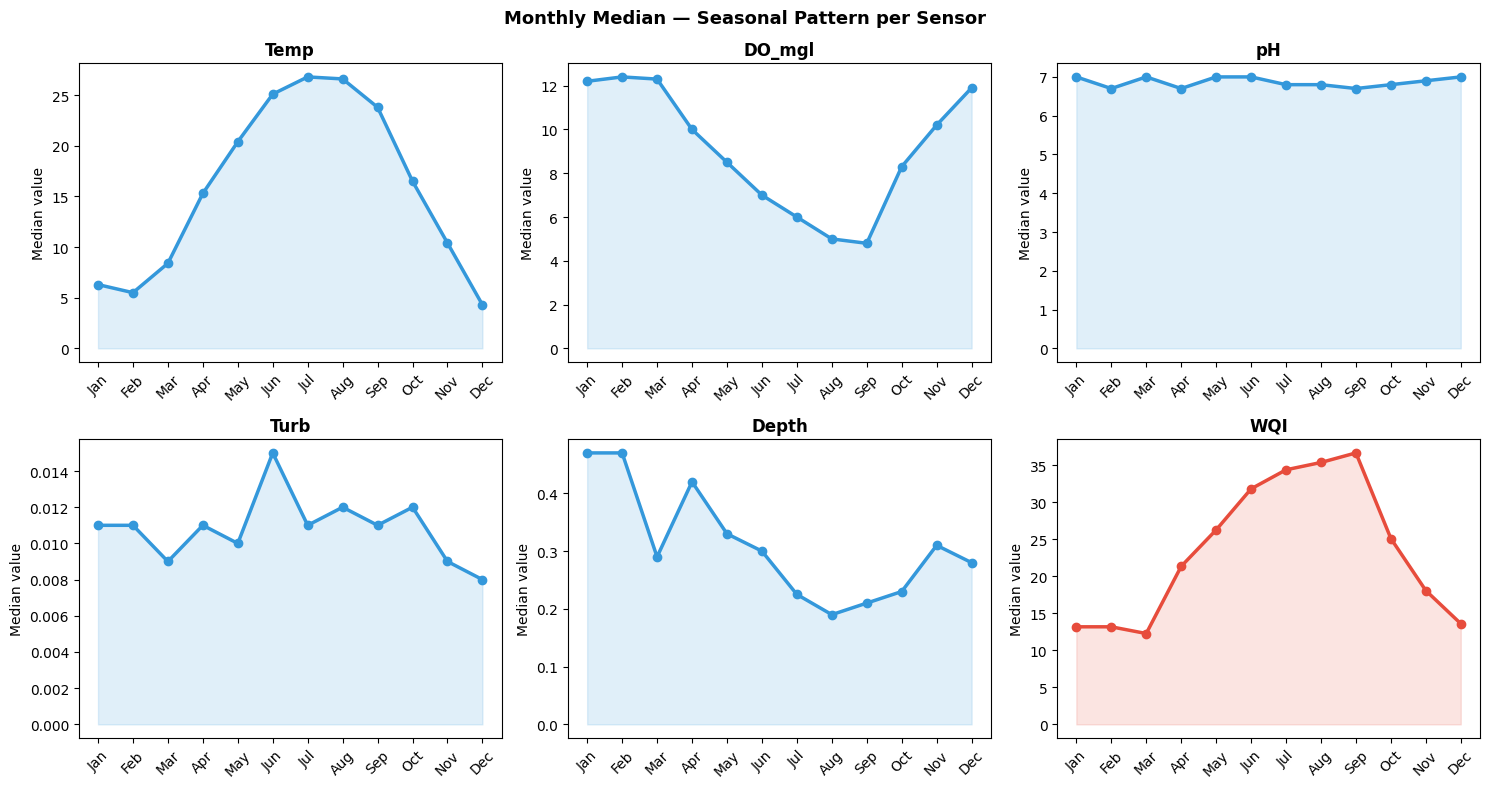

In [35]:
#   "Every sensor peaks in summer and drops in winter, just like WQI.
#    Month of year is one of the most important model features."

cols_to_plot = ['Temp', 'DO_mgl', 'pH', 'Turb', 'Depth', 'WQI']
monthly      = df.groupby('month')[cols_to_plot].median()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Monthly Median — Seasonal Pattern per Sensor', fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cols_to_plot):
    ax    = axes[i]
    color = '#e74c3c' if col == 'WQI' else '#3498db'
    ax.plot(monthly.index, monthly[col], marker='o', linewidth=2.5, color=color)
    ax.fill_between(monthly.index, monthly[col], alpha=0.15, color=color)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS, rotation=45)
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('Median value')

plt.tight_layout()
plt.show()

In [38]:
# Text bar — easy to read aloud to manager
print('WQI median by month:\n')
for m, v in monthly['WQI'].items():
    print(f'  {MONTH_LABELS[m-1]}  {v:5.1f}  {chr(9608) * int(v/2)}')

WQI median by month:

  Jan   13.2  ██████
  Feb   13.2  ██████
  Mar   12.3  ██████
  Apr   21.4  ██████████
  May   26.3  █████████████
  Jun   31.8  ███████████████
  Jul   34.4  █████████████████
  Aug   35.4  █████████████████
  Sep   36.7  ██████████████████
  Oct   25.1  ████████████
  Nov   18.1  █████████
  Dec   13.6  ██████


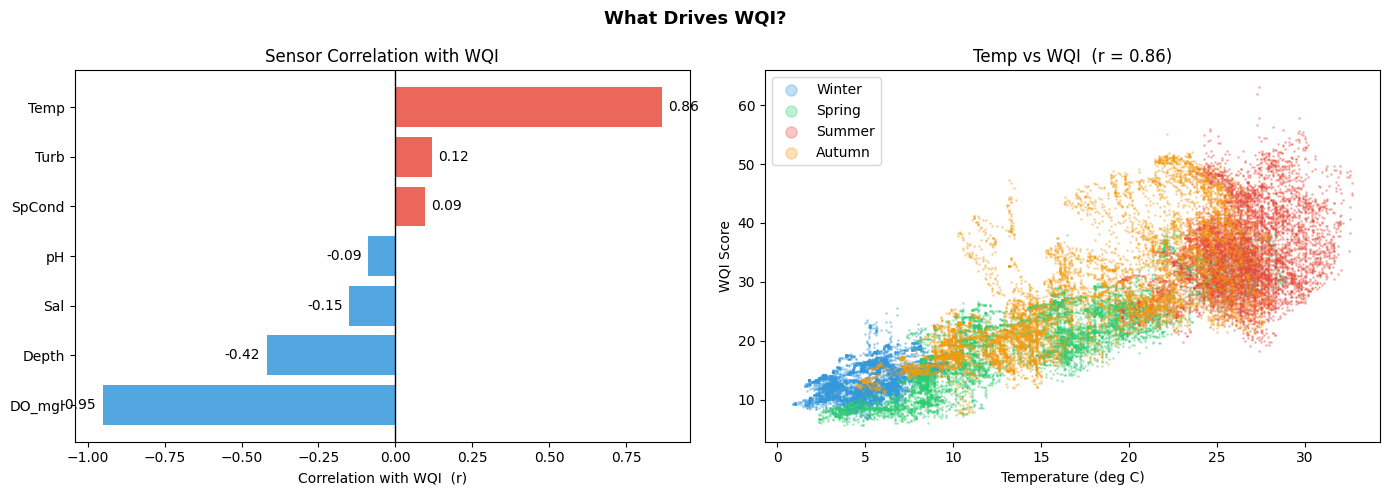

In [39]:
#   "Temperature (r=+0.86) and Dissolved Oxygen (r=−0.95) almost completely
#    explain WQI. These are the two most powerful features for any model."

sensor_cols   = ['Temp', 'SpCond', 'Sal', 'DO_mgl', 'Depth', 'pH', 'Turb']
corr_with_wqi = df[sensor_cols + ['WQI']].corr()['WQI'].drop('WQI').sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('What Drives WQI?', fontsize=13, fontweight='bold')

# Left: bar chart of each sensor's correlation with WQI
ax = axes[0]
bar_colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_with_wqi.values]
bars = ax.barh(corr_with_wqi.index, corr_with_wqi.values, color=bar_colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Correlation with WQI  (r)')
ax.set_title('Sensor Correlation with WQI')
for bar, val in zip(bars, corr_with_wqi.values):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=10)

# Right: Temperature vs WQI scatter coloured by season
ax2 = axes[1]
for season, color in SEASON_COLORS.items():
    mask = df['season'] == season
    ax2.scatter(df.loc[mask, 'Temp'], df.loc[mask, 'WQI'],
                s=1, alpha=0.3, color=color, label=season)
ax2.set_xlabel('Temperature (deg C)')
ax2.set_ylabel('WQI Score')
ax2.set_title(f'Temp vs WQI  (r = {corr_with_wqi["Temp"]:.2f})')
ax2.legend(markerscale=8)

plt.tight_layout()
plt.show()


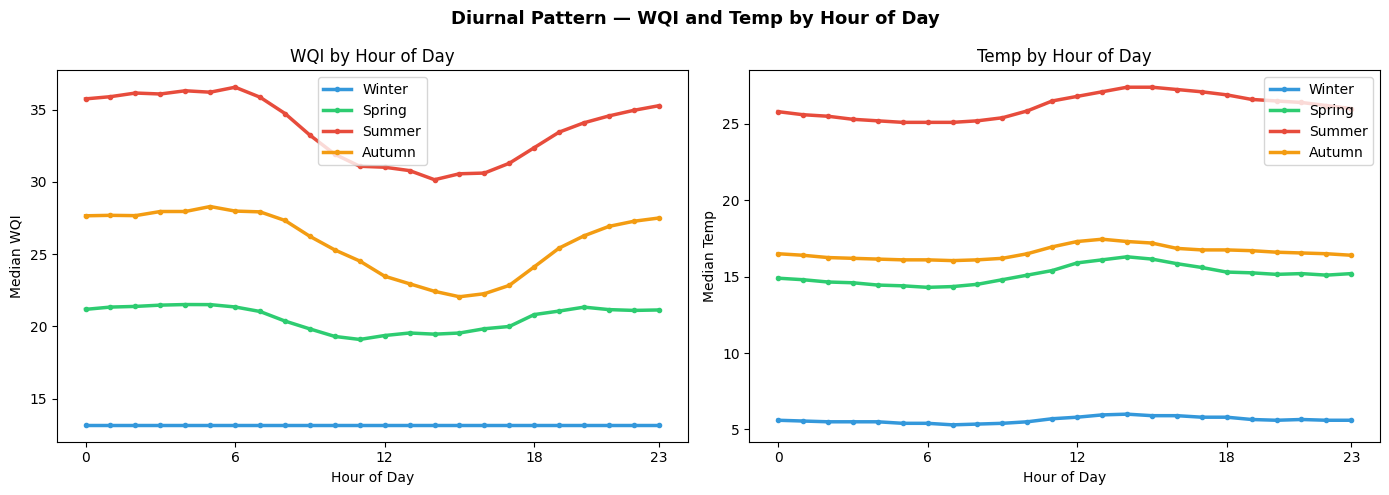

In [40]:
#   "Even within a single day WQI follows a predictable hourly pattern.
#    The effect is strongest in summer — this is why we added sin/cos hour features."

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Diurnal Pattern — WQI and Temp by Hour of Day', fontsize=13, fontweight='bold')

for ax, col in zip(axes, ['WQI', 'Temp']):
    for season, color in SEASON_COLORS.items():
        hourly = df[df['season'] == season].groupby('hour')[col].median()
        ax.plot(hourly.index, hourly.values,
                label=season, color=color, linewidth=2.5, marker='o', markersize=3)
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel(f'Median {col}')
    ax.set_title(f'{col} by Hour of Day')
    ax.set_xticks([0, 6, 12, 18, 23])
    ax.legend()

plt.tight_layout()
plt.show()

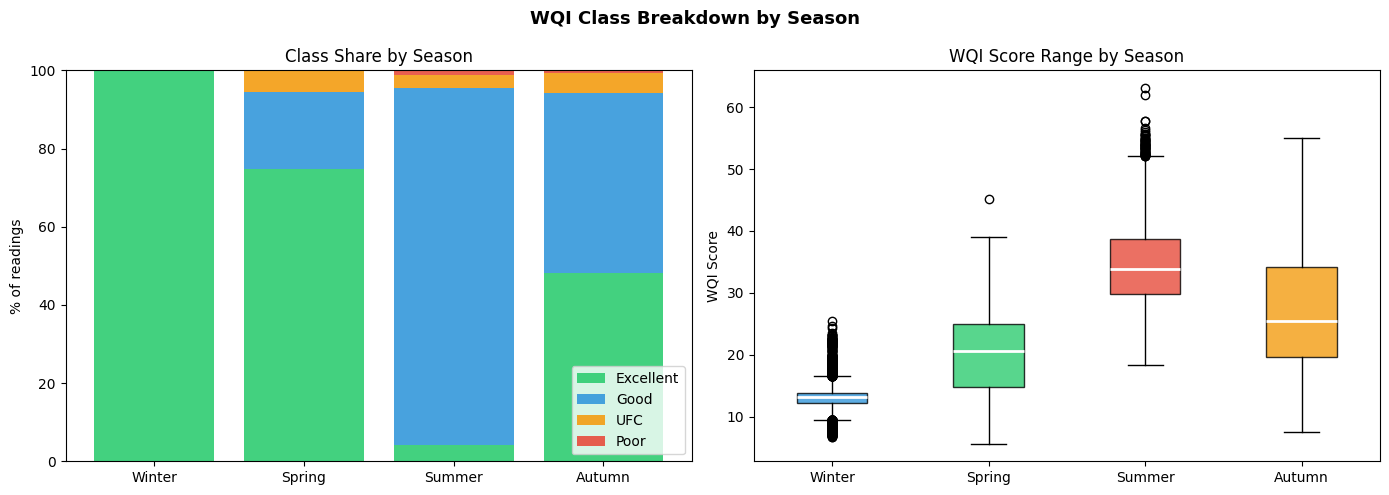

WQI Class % by Season:
WQI_Class  Excellent  Good  UFC  Poor
season                               
Winter         100.0   0.0  0.0   0.0
Spring          74.8  19.6  5.5   0.0
Summer           4.2  91.2  3.5   1.1
Autumn          48.2  45.9  5.3   0.6


In [41]:
#   "In Winter 100% of readings are Excellent.
#    Poor quality only appears in Summer and Autumn — season is the strongest risk predictor."

tbl = (df.groupby(['season', 'WQI_Class'])
          .size()
          .unstack(fill_value=0)
          .reindex(SEASON_ORDER)[CLASS_ORDER])
tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('WQI Class Breakdown by Season', fontsize=13, fontweight='bold')

# Left: stacked bar — % per class per season
ax = axes[0]
bottom = np.zeros(len(SEASON_ORDER))
x = np.arange(len(SEASON_ORDER))
for cls in CLASS_ORDER:
    ax.bar(x, tbl_pct[cls], bottom=bottom,
           label=cls, color=CLASS_COLORS[cls], alpha=0.9)
    bottom += tbl_pct[cls].values
ax.set_xticks(x)
ax.set_xticklabels(SEASON_ORDER)
ax.set_ylabel('% of readings')
ax.set_title('Class Share by Season')
ax.legend(loc='lower right')

# Right: boxplot — WQI score spread per season
ax2 = axes[1]
data_by_season = [df[df['season'] == s]['WQI'].values for s in SEASON_ORDER]
bp = ax2.boxplot(data_by_season, patch_artist=True,
                 medianprops={'color': 'white', 'linewidth': 2})
for patch, season in zip(bp['boxes'], SEASON_ORDER):
    patch.set_facecolor(SEASON_COLORS[season])
    patch.set_alpha(0.8)
ax2.set_xticklabels(SEASON_ORDER)
ax2.set_ylabel('WQI Score')
ax2.set_title('WQI Score Range by Season')

plt.tight_layout()
plt.show()

print('WQI Class % by Season:')
print(tbl_pct.round(1).to_string())

Total rows      : 37,730
Original rows   : 37,730  (100.0%)
Gap-filled rows : 0  (0.0%)


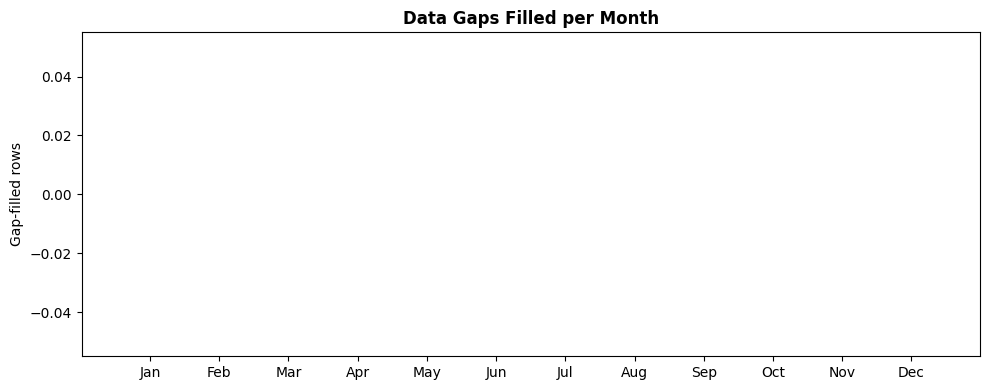

In [42]:
#   "12.2% of timestamps had missing sensor data.
#    We filled them with forward-fill and flagged each row so the model knows."

imp_cols      = [c for c in df.columns if 'was_imputed' in c]
df['any_gap'] = df[imp_cols].any(axis=1)

total    = len(df)
imputed  = int(df['any_gap'].sum())
original = total - imputed

print(f'Total rows      : {total:,}')
print(f'Original rows   : {original:,}  ({100*original/total:.1f}%)')
print(f'Gap-filled rows : {imputed:,}  ({100*imputed/total:.1f}%)')

monthly_gaps = df.groupby('month')['any_gap'].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(monthly_gaps.index, monthly_gaps.values, color='#e74c3c', alpha=0.75)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS)
ax.set_ylabel('Gap-filled rows')
ax.set_title('Data Gaps Filled per Month', fontweight='bold')
plt.tight_layout()
plt.show()

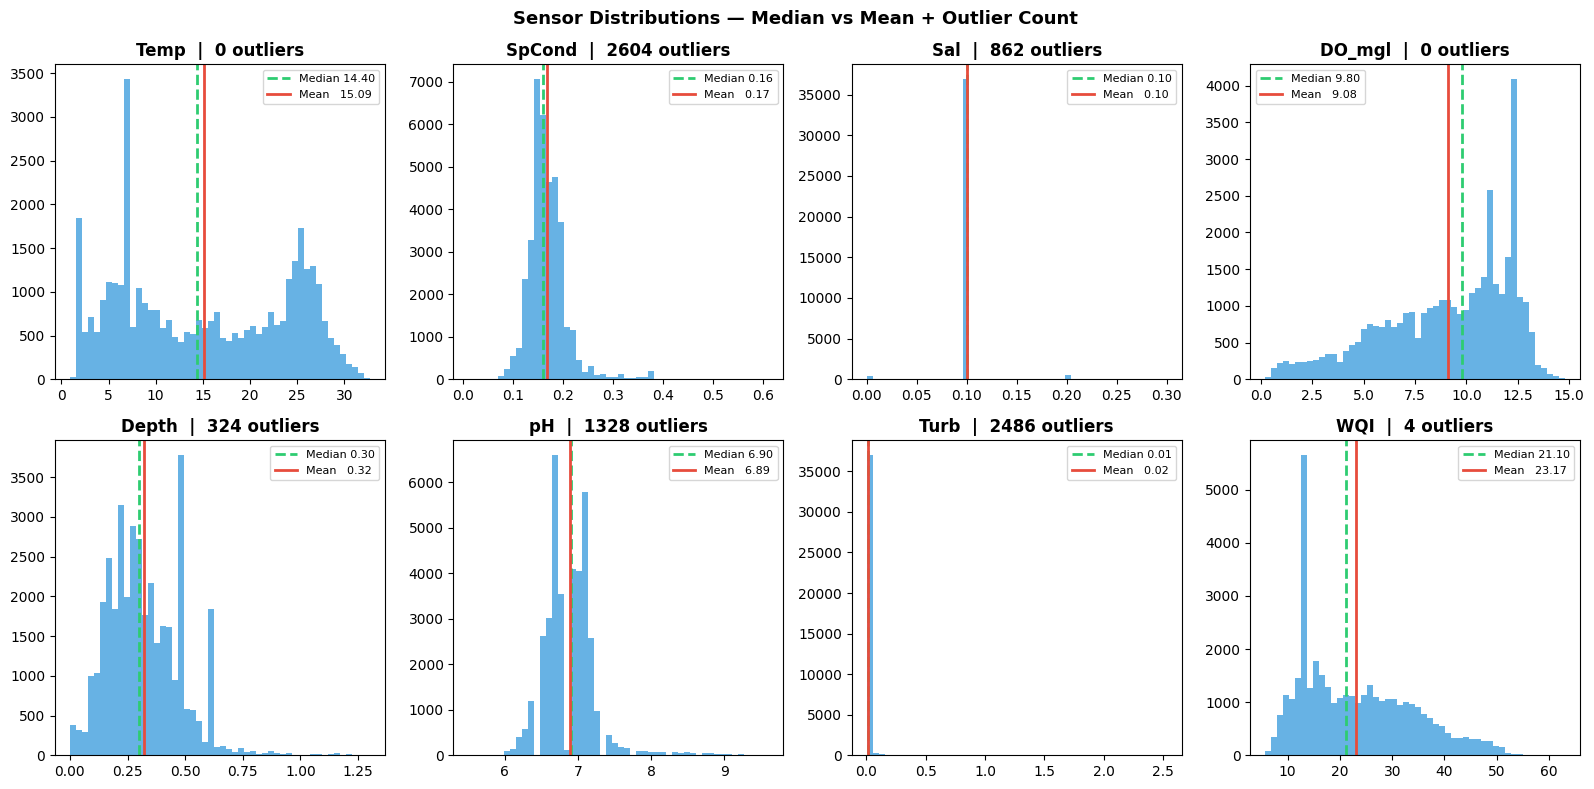

Stats summary:
         min   mean  median    max
Temp    0.90  15.09   14.40  32.70
SpCond  0.01   0.17    0.16   0.61
Sal     0.00   0.10    0.10   0.30
DO_mgl  0.20   9.08    9.80  14.80
Depth   0.00   0.32    0.30   1.30
pH      5.50   6.89    6.90   9.60
Turb    0.00   0.02    0.01   2.53
WQI     5.70  23.17   21.10  63.06


In [43]:
#   "Most sensors are clean and well-behaved.
#    Turbidity has extreme spikes — likely real storm events, not errors."

all_cols = ['Temp', 'SpCond', 'Sal', 'DO_mgl', 'Depth', 'pH', 'Turb', 'WQI']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Sensor Distributions — Median vs Mean + Outlier Count',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(all_cols):
    ax   = axes[i]
    data = df[col].dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    n_out = int(((data < q1 - 1.5*(q3-q1)) | (data > q3 + 1.5*(q3-q1))).sum())

    ax.hist(data, bins=50, color='#3498db', alpha=0.75, edgecolor='none')
    ax.axvline(data.median(), color='#2ecc71', linewidth=2,
               linestyle='--', label=f'Median {data.median():.2f}')
    ax.axvline(data.mean(),   color='#e74c3c', linewidth=2,
               linestyle='-',  label=f'Mean   {data.mean():.2f}')
    ax.set_title(f'{col}  |  {n_out} outliers', fontweight='bold')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print('Stats summary:')
print(df[all_cols].agg(['min', 'mean', 'median', 'max']).T.round(2).to_string())

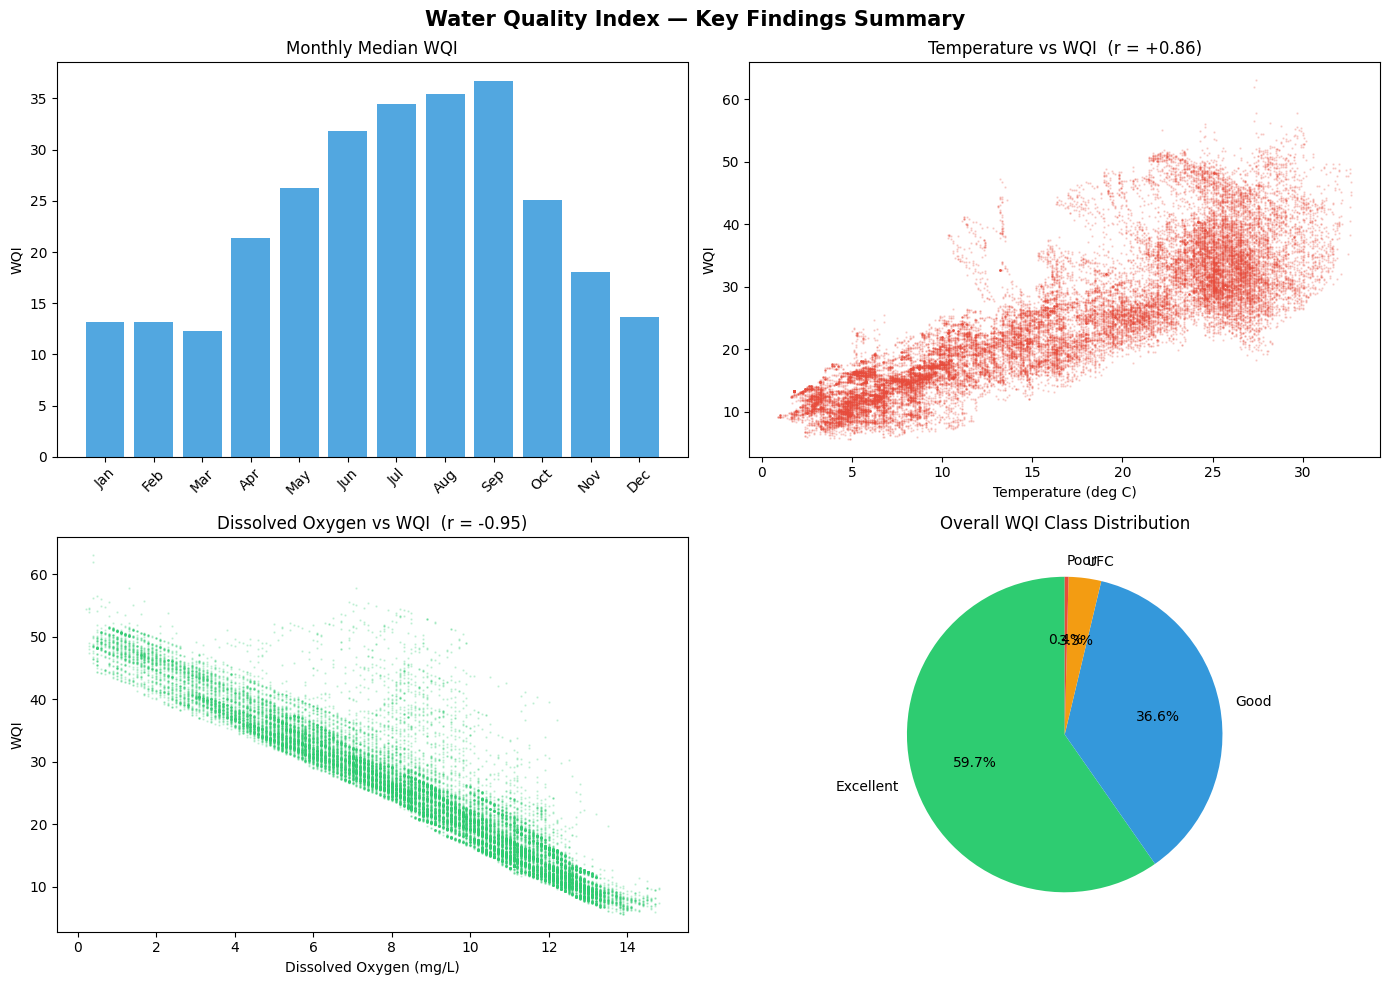

Chart saved as wqi_summary_for_manager.png


In [44]:
# Save this chart and show it in your manager meeting.

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Water Quality Index — Key Findings Summary', fontsize=15, fontweight='bold')

# Top-left: WQI by month
ax = axes[0][0]
m = df.groupby('month')['WQI'].median()
ax.bar(m.index, m.values, color='#3498db', alpha=0.85)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS, rotation=45)
ax.set_title('Monthly Median WQI')
ax.set_ylabel('WQI')

# Top-right: Temperature vs WQI
ax = axes[0][1]
ax.scatter(df['Temp'], df['WQI'], s=0.5, alpha=0.2, color='#e74c3c')
ax.set_xlabel('Temperature (deg C)')
ax.set_ylabel('WQI')
ax.set_title('Temperature vs WQI  (r = +0.86)')

# Bottom-left: Dissolved Oxygen vs WQI
ax = axes[1][0]
ax.scatter(df['DO_mgl'], df['WQI'], s=0.5, alpha=0.2, color='#2ecc71')
ax.set_xlabel('Dissolved Oxygen (mg/L)')
ax.set_ylabel('WQI')
ax.set_title('Dissolved Oxygen vs WQI  (r = -0.95)')

# Bottom-right: class pie chart
ax = axes[1][1]
counts = df['WQI_Class'].value_counts().reindex(CLASS_ORDER)
ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
       colors=[CLASS_COLORS[c] for c in counts.index], startangle=90)
ax.set_title('Overall WQI Class Distribution')

plt.tight_layout()
plt.savefig('wqi_summary_for_manager.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as wqi_summary_for_manager.png')